
# 03 — Modeling Axe 3 (Version 2)

**Projet :** Stroke Prediction AI  
**Notebook 3 :** Modeling pour l’Axe 3 — Mortality Prediction  
**Dataset utilisé :** données preprocessées issues du notebook **Preprocessing V2**  
**Environnement ciblé :** Google Colab

---

## 1. Problèmes identifiés dans la Version 1

La Version 1 du modeling a permis d’obtenir une première base de comparaison. Cependant, plusieurs limites ont été observées :

### 1. Déséquilibre des classes mal géré
Les distributions de `DDEAD` et `FDEAD` restent déséquilibrées :
- beaucoup plus de survivants que de décès ;
- biais des modèles vers la classe majoritaire.

**Conséquence observée :**  
Le modèle **Random Forest** obtenait une accuracy élevée, mais un **Recall très faible**, ce qui signifie qu’il ratait de nombreux patients à risque.

### 2. Accuracy trompeuse
Dans un problème médical déséquilibré, l’accuracy seule n’est pas suffisante.  
Un modèle peut sembler bon globalement tout en détectant mal les décès.

### 3. Modèles V1 trop basiques
La Version 1 reposait surtout sur :
- Régression Logistique ;
- Random Forest.

Ces modèles constituent de bonnes baselines, mais restent limités pour capturer des relations plus complexes.

### 4. Pas de rééquilibrage explicite des données
La V1 utilisait `class_weight="balanced"`, mais **pas de stratégie de rééchantillonnage** comme **SMOTE**.

### 5. Optimisation insuffisante pour le Recall
Or, selon le cahier des charges, pour l’Axe 3, il faut **privilégier le Recall** afin de minimiser les faux négatifs cliniquement dangereux.

---

## 2. Objectif du Modeling V2

=>Construire une version de modélisation plus performante et plus adaptée au contexte médical, en améliorant particulièrement :

- le **Recall** ;
- la gestion du **déséquilibre des classes** ;
- la comparaison entre modèles ;
- la robustesse de l’évaluation.

---

## 3. Ce qu’on va améliorer

###  1. Utilisation de SMOTE
Le rééquilibrage sera appliqué **uniquement sur les données d’entraînement**, afin d’éviter toute fuite d’information.

###  2. Ajout d’un modèle plus puissant
En plus des baselines, on introduit **XGBoost**, souvent performant sur des données tabulaires médicales.

###  3. Focus sur les métriques cliniques
On mettra l’accent sur :
- **Recall**
- **AUC-ROC**
- **F1-score**
- **Confusion Matrix**

###  4. Comparaison plus structurée
Les modèles seront comparés proprement pour :
- `DDEAD` (14 jours)
- `FDEAD` (6 mois)

###  5. Sauvegarde des meilleurs modèles
Les meilleurs modèles seront sauvegardés dans Google Drive pour une réutilisation ultérieure.



## Objectif général du notebook

Ce notebook vise à entraîner et comparer plusieurs modèles pour la prédiction de la mortalité post-AVC :

- `DDEAD` : mortalité à **14 jours**
- `FDEAD` : mortalité à **6 mois**

Les données d’entrée proviennent directement du notebook **Preprocessing V2** :
- `X_ddead_preprocessed_v2.csv`
- `y_ddead_preprocessed_v2.csv`
- `X_fdead_preprocessed_v2.csv`
- `y_fdead_preprocessed_v2.csv`



## Installation des dépendances

Ce notebook utilise :
- `imbalanced-learn` pour **SMOTE**
- `xgboost` pour le modèle **XGBoost**

Sur Google Colab, cette cellule peut être exécutée une seule fois au début.


In [1]:

# =========================
# 1. INSTALLATION DES PACKAGES
# =========================

!pip install -q imbalanced-learn xgboost


In [2]:

# =========================
# 2. IMPORTATION DES LIBRAIRIES
# =========================
# Cette section importe les bibliothèques nécessaires
# à la lecture des données, à l'entraînement des modèles,
# au rééquilibrage par SMOTE et à l'évaluation.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Options d'affichage
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)



## Chargement des données preprocessées depuis Google Drive

Ce notebook est conçu pour fonctionner sur **Google Colab**.  
On monte donc Google Drive, puis on charge les fichiers générés par le notebook **Preprocessing V2**.


In [3]:

# =========================
# 3. CHARGEMENT DES DONNEES PREPROCESSEES
# =========================

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Stroke_Project_ML/Data/"

X_ddead = pd.read_csv(base_path + "X_ddead_preprocessed_v2.csv")
y_ddead = pd.read_csv(base_path + "y_ddead_preprocessed_v2.csv").squeeze()

X_fdead = pd.read_csv(base_path + "X_fdead_preprocessed_v2.csv")
y_fdead = pd.read_csv(base_path + "y_fdead_preprocessed_v2.csv").squeeze()

# Sécurisation des types
y_ddead = pd.to_numeric(y_ddead, errors="coerce").astype(int)
y_fdead = pd.to_numeric(y_fdead, errors="coerce").astype(int)

print("Chargement terminé.")
print("X_ddead :", X_ddead.shape)
print("y_ddead :", y_ddead.shape)
print("X_fdead :", X_fdead.shape)
print("y_fdead :", y_fdead.shape)


Mounted at /content/drive
Chargement terminé.
X_ddead : (19410, 20)
y_ddead : (19410,)
X_fdead : (19279, 20)
y_fdead : (19279,)



## Vérification des distributions de classes

Avant toute modélisation, il est important d’observer la distribution des classes afin de :
- confirmer le déséquilibre ;
- justifier l’utilisation de **SMOTE** ;
- mieux interpréter les résultats.


In [4]:

# =========================
# 4. VERIFICATION DES CLASSES
# =========================

print("Distribution de y_ddead :")
print(y_ddead.value_counts())
print()

print("Distribution de y_fdead :")
print(y_fdead.value_counts())


Distribution de y_ddead :
DDEAD
0    17376
1     2034
Name: count, dtype: int64

Distribution de y_fdead :
FDEAD
0    14910
1     4369
Name: count, dtype: int64


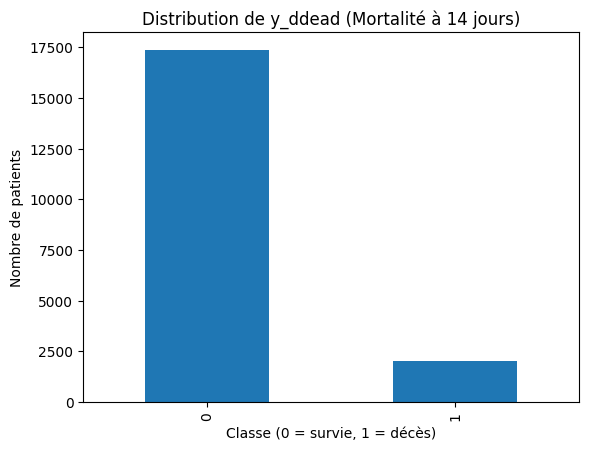

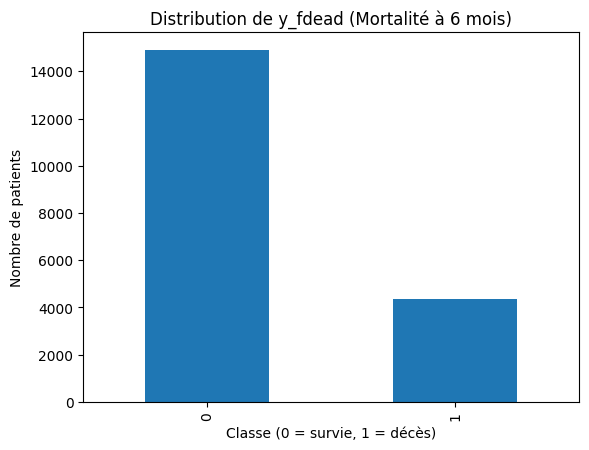

In [5]:

# =========================
# 5. VISUALISATION DES CLASSES
# =========================

plt.figure()
y_ddead.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de y_ddead (Mortalité à 14 jours)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")
plt.show()

plt.figure()
y_fdead.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution de y_fdead (Mortalité à 6 mois)")
plt.xlabel("Classe (0 = survie, 1 = décès)")
plt.ylabel("Nombre de patients")
plt.show()



## Séparation train / test

On sépare les données en :
- **80 % pour l’entraînement**
- **20 % pour le test**

On utilise `stratify=y` afin de conserver la distribution des classes dans les deux sous-ensembles.


In [6]:

# =========================
# 6. TRAIN / TEST SPLIT
# =========================

X_train_ddead, X_test_ddead, y_train_ddead, y_test_ddead = train_test_split(
    X_ddead,
    y_ddead,
    test_size=0.2,
    random_state=42,
    stratify=y_ddead
)

X_train_fdead, X_test_fdead, y_train_fdead, y_test_fdead = train_test_split(
    X_fdead,
    y_fdead,
    test_size=0.2,
    random_state=42,
    stratify=y_fdead
)

print("DDEAD - Train :", X_train_ddead.shape, "| Test :", X_test_ddead.shape)
print("FDEAD - Train :", X_train_fdead.shape, "| Test :", X_test_fdead.shape)


DDEAD - Train : (15528, 20) | Test : (3882, 20)
FDEAD - Train : (15423, 20) | Test : (3856, 20)



## Rééquilibrage des données avec SMOTE

Dans cette Version 2, on applique **SMOTE** uniquement sur les données d’entraînement.

### Pourquoi seulement sur l’entraînement ?
Parce qu’il ne faut jamais rééquilibrer le jeu de test.  
Sinon, on introduit une fuite d’information et on fausse l’évaluation finale.


In [7]:

# =========================
# 7. APPLICATION DE SMOTE
# =========================

smote = SMOTE(random_state=42)

# Rééquilibrage pour DDEAD
X_train_ddead_smote, y_train_ddead_smote = smote.fit_resample(X_train_ddead, y_train_ddead)

# Rééquilibrage pour FDEAD
X_train_fdead_smote, y_train_fdead_smote = smote.fit_resample(X_train_fdead, y_train_fdead)

print("Distribution après SMOTE - DDEAD :")
print(pd.Series(y_train_ddead_smote).value_counts())
print()

print("Distribution après SMOTE - FDEAD :")
print(pd.Series(y_train_fdead_smote).value_counts())


Distribution après SMOTE - DDEAD :
DDEAD
0    13901
1    13901
Name: count, dtype: int64

Distribution après SMOTE - FDEAD :
FDEAD
0    11928
1    11928
Name: count, dtype: int64



## Définition des modèles de la Version 2

On compare ici trois modèles :

### 1. Logistic Regression
Baseline simple et interprétable.

### 2. Random Forest
Modèle non linéaire capable de capter des interactions plus complexes.

### 3. XGBoost
Modèle boosting puissant, souvent performant sur données tabulaires structurées.


In [8]:

# =========================
# 8. DEFINITION DES MODELES
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42
    )
}



## Fonction d’évaluation

Pour chaque modèle, on va :
1. entraîner le modèle ;
2. prédire les classes ;
3. calculer les probabilités ;
4. afficher les métriques principales ;
5. visualiser la matrice de confusion ;
6. stocker les résultats dans un tableau récapitulatif.


In [9]:

# =========================
# 9. FONCTION D'EVALUATION
# =========================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, target_name):
    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)

    # Probabilités
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    # Métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan

    print("=" * 70)
    print(f"Target : {target_name}")
    print(f"Modèle : {model_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matrice de confusion - {model_name} - {target_name}")
    plt.show()

    return {
        "Target": target_name,
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "AUC-ROC": auc
    }



## Modélisation sur `DDEAD`

On entraîne maintenant les trois modèles sur les données **rééquilibrées par SMOTE** pour la cible `DDEAD` (mortalité à 14 jours), puis on évalue les performances sur le jeu de test réel.


Target : DDEAD
Modèle : Logistic Regression
Accuracy  : 0.7566
Precision : 0.2581
Recall    : 0.7052
F1-score  : 0.3779
AUC-ROC   : 0.7943

Classification Report :
              precision    recall  f1-score   support

           0       0.96      0.76      0.85      3475
           1       0.26      0.71      0.38       407

    accuracy                           0.76      3882
   macro avg       0.61      0.73      0.61      3882
weighted avg       0.88      0.76      0.80      3882



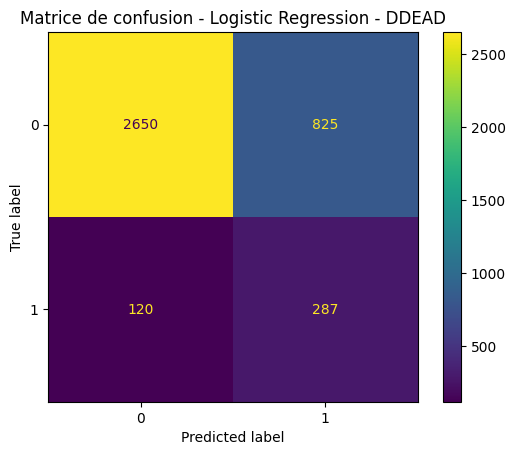

Target : DDEAD
Modèle : Random Forest
Accuracy  : 0.8861
Precision : 0.3504
Recall    : 0.1007
F1-score  : 0.1565
AUC-ROC   : 0.7609

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      3475
           1       0.35      0.10      0.16       407

    accuracy                           0.89      3882
   macro avg       0.63      0.54      0.55      3882
weighted avg       0.84      0.89      0.86      3882



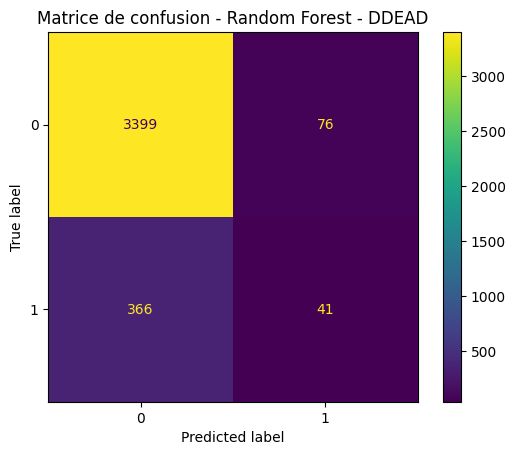

Target : DDEAD
Modèle : XGBoost
Accuracy  : 0.8972
Precision : 0.5571
Recall    : 0.0958
F1-score  : 0.1635
AUC-ROC   : 0.7923

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      3475
           1       0.56      0.10      0.16       407

    accuracy                           0.90      3882
   macro avg       0.73      0.54      0.55      3882
weighted avg       0.87      0.90      0.86      3882



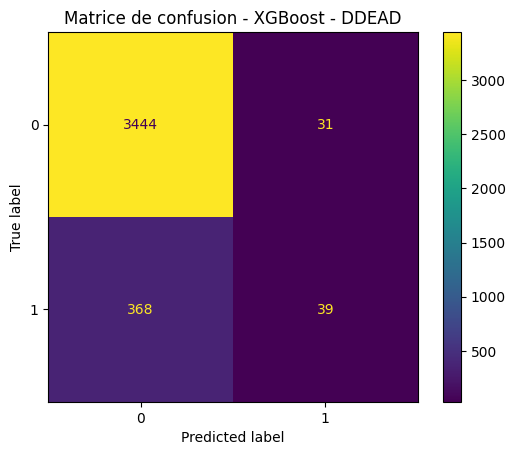

In [10]:

# =========================
# 10. MODELISATION SUR DDEAD
# =========================

results_ddead = []

for model_name, model in models.items():
    result = evaluate_model(
        model=model,
        X_train=X_train_ddead_smote,
        X_test=X_test_ddead,
        y_train=y_train_ddead_smote,
        y_test=y_test_ddead,
        model_name=model_name,
        target_name="DDEAD"
    )
    results_ddead.append(result)



## Modélisation sur `FDEAD`

On applique maintenant la même logique à `FDEAD` (mortalité à 6 mois).


Target : FDEAD
Modèle : Logistic Regression
Accuracy  : 0.7417
Precision : 0.4554
Recall    : 0.7128
F1-score  : 0.5558
AUC-ROC   : 0.7988

Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      2982
           1       0.46      0.71      0.56       874

    accuracy                           0.74      3856
   macro avg       0.68      0.73      0.69      3856
weighted avg       0.80      0.74      0.76      3856



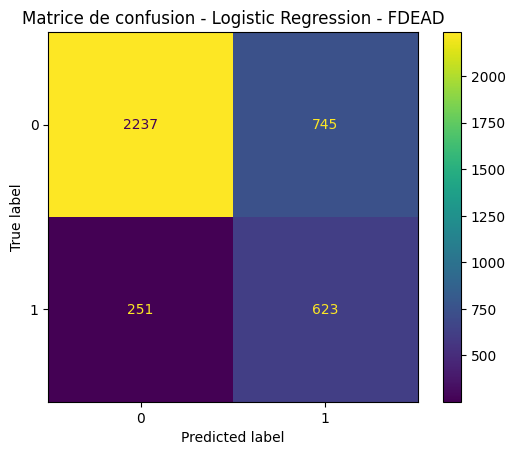

Target : FDEAD
Modèle : Random Forest
Accuracy  : 0.7930
Precision : 0.5657
Recall    : 0.3741
F1-score  : 0.4504
AUC-ROC   : 0.7648

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      2982
           1       0.57      0.37      0.45       874

    accuracy                           0.79      3856
   macro avg       0.70      0.64      0.66      3856
weighted avg       0.77      0.79      0.78      3856



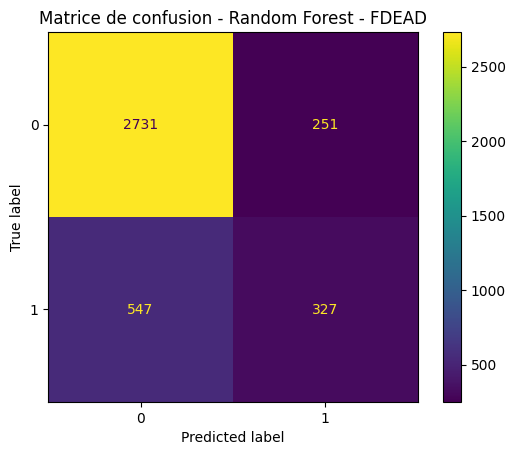

Target : FDEAD
Modèle : XGBoost
Accuracy  : 0.8024
Precision : 0.6081
Recall    : 0.3604
F1-score  : 0.4526
AUC-ROC   : 0.7978

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      2982
           1       0.61      0.36      0.45       874

    accuracy                           0.80      3856
   macro avg       0.72      0.65      0.67      3856
weighted avg       0.78      0.80      0.78      3856



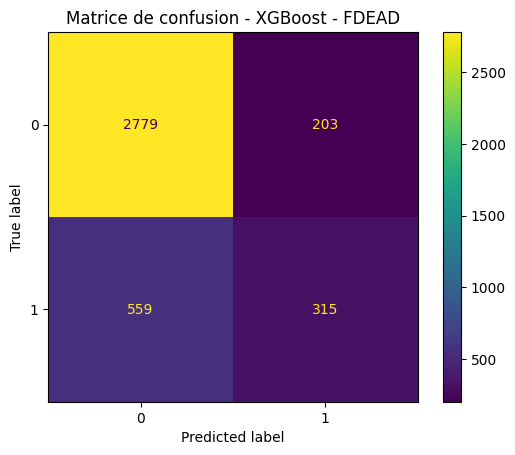

In [11]:

# =========================
# 11. MODELISATION SUR FDEAD
# =========================

results_fdead = []

for model_name, model in models.items():
    result = evaluate_model(
        model=model,
        X_train=X_train_fdead_smote,
        X_test=X_test_fdead,
        y_train=y_train_fdead_smote,
        y_test=y_test_fdead,
        model_name=model_name,
        target_name="FDEAD"
    )
    results_fdead.append(result)



## Tableau récapitulatif des résultats

On rassemble maintenant tous les résultats dans deux tableaux :
- un pour `DDEAD`
- un pour `FDEAD`

Le classement est effectué selon le **Recall**, car c’est la métrique la plus importante pour cet axe.


In [12]:

# =========================
# 12. TABLEAUX RECAPITULATIFS
# =========================

results_df_ddead = pd.DataFrame(results_ddead).sort_values(by="Recall", ascending=False)
results_df_fdead = pd.DataFrame(results_fdead).sort_values(by="Recall", ascending=False)

print("Résultats - DDEAD")
display(results_df_ddead)

print("Résultats - FDEAD")
display(results_df_fdead)


Résultats - DDEAD


,Target,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,DDEAD,Logistic Regression,0.756569,0.258094,0.705160,0.377880,0.794262
1,DDEAD,Random Forest,0.886141,0.350427,0.100737,0.156489,0.760868
2,DDEAD,XGBoost,0.897218,0.557143,0.095823,0.163522,0.792257


Résultats - FDEAD


,Target,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,FDEAD,Logistic Regression,0.741701,0.455409,0.712815,0.555754,0.798841
1,FDEAD,Random Forest,0.793050,0.565744,0.374142,0.450413,0.764828
2,FDEAD,XGBoost,0.802386,0.608108,0.360412,0.452586,0.797779



## Interprétation des résultats

Dans le contexte médical, le **Recall** est prioritaire.  
Un faux négatif signifie qu’un patient réellement à risque est classé comme non à risque.

### Ce qu’il faut observer dans cette V2
- si le Recall augmente par rapport à la V1 ;
- si SMOTE améliore la détection des décès ;
- si XGBoost apporte un gain par rapport aux modèles de base ;
- si le compromis précision / rappel reste acceptable.


In [13]:

# =========================
# 13. SELECTION DES MEILLEURS MODELES
# =========================

best_model_ddead_name = results_df_ddead.iloc[0]["Model"]
best_model_fdead_name = results_df_fdead.iloc[0]["Model"]

print("Meilleur modèle pour DDEAD (selon Recall) :", best_model_ddead_name)
print("Meilleur modèle pour FDEAD (selon Recall) :", best_model_fdead_name)


Meilleur modèle pour DDEAD (selon Recall) : Logistic Regression
Meilleur modèle pour FDEAD (selon Recall) : Logistic Regression



## Réentraînement des meilleurs modèles

On réentraîne les meilleurs modèles sélectionnés sur les données d’entraînement rééquilibrées correspondantes afin de préparer leur sauvegarde.


In [14]:

# =========================
# 14. REENTRAINEMENT DES MEILLEURS MODELES
# =========================

best_model_ddead = models[best_model_ddead_name]
best_model_fdead = models[best_model_fdead_name]

best_model_ddead.fit(X_train_ddead_smote, y_train_ddead_smote)
best_model_fdead.fit(X_train_fdead_smote, y_train_fdead_smote)

print("Les meilleurs modèles ont été réentraînés avec succès.")


Les meilleurs modèles ont été réentraînés avec succès.



## Sauvegarde des modèles

Les meilleurs modèles de la Version 2 sont sauvegardés dans Google Drive pour être réutilisés plus tard dans l’application ou dans des notebooks d’inférence.


In [15]:

# =========================
# 15. SAUVEGARDE DES MODELES
# =========================

import os
import joblib

save_dir = "/content/drive/MyDrive/Stroke_Project_ML/Models/"
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_model_ddead, save_dir + "best_model_ddead_v2.pkl")
joblib.dump(best_model_fdead, save_dir + "best_model_fdead_v2.pkl")

print("Modèles V2 sauvegardés avec succès.")


Modèles V2 sauvegardés avec succès.



## Conclusion

Cette **Version 2 du modeling** améliore la Version 1 grâce à :
- l’utilisation de **SMOTE** pour le rééquilibrage des classes ;
- l’ajout d’un modèle plus puissant avec **XGBoost** ;
- une comparaison plus robuste entre les modèles ;
- une évaluation centrée sur les métriques cliniquement pertinentes, notamment le **Recall**.

### Résultat attendu
Cette version doit permettre :
- une meilleure détection des patients à risque ;
- une réduction du nombre de faux négatifs ;
- une amélioration globale de la pertinence clinique du modèle.

### Étapes futures possibles
- tuning des hyperparamètres ;
- optimisation du seuil de décision ;
- interprétabilité avec SHAP ;
- validation croisée.
